## **Heart Disease Dataset: Exploratory Visualization**

### **Myocardial infarction**


A myocardial infarction (MI), commonly known as a heart attack, occurs when blood flow decreases or stops to the coronary artery of the heart, causing damage to the heart muscle. The most common symptom is chest pain or discomfort which may travel into the shoulder, arm, back, neck or jaw. Often it occurs in the center or left side of the chest and lasts for more than a few minutes. The discomfort may occasionally feel like heartburn. Other symptoms may include shortness of breath, nausea, feeling faint, a cold sweat or feeling tired. About 30% of people have atypical symptoms. Women more often present without chest pain and instead have neck pain, arm pain or feel tired. Among those over 75 years old, about 5% have had an MI with little or no history of symptoms. An MI may cause heart failure, an irregular heartbeat, cardiogenic shock or cardiac arrest.

Most MIs occur due to coronary artery disease. Risk factors include high blood pressure, smoking, diabetes, lack of exercise, obesity, high blood cholesterol, poor diet and excessive alcohol intake. The complete blockage of a coronary artery caused by a rupture of an atherosclerotic plaque is usually the underlying mechanism of an MI. MIs are less commonly caused by coronary artery spasms, which may be due to cocaine, significant emotional stress (commonly known as Takotsubo syndrome or broken heart syndrome) and extreme cold, among others.

![https://www.hopkinsmedicine.org/-/media/images/health/3_-wellness/heart-health/heart-hero.ashx?h=500&iar=0&mh=500&mw=1300&w=1297&hash=E47E5436438DB44D675FE9442C5ADBFC](https://www.hopkinsmedicine.org/-/media/images/health/3_-wellness/heart-health/heart-hero.ashx?h=500&iar=0&mh=500&mw=1300&w=1297&hash=E47E5436438DB44D675FE9442C5ADBFC)


> Source: https://en.wikipedia.org/wiki/Myocardial_infarction

> Source: https://www.hopkinsmedicine.org/health/wellness-and-prevention/the-heart-test-you-may-need-but-likely-havent-heard-of

## **Let's start!**

In [1]:
# Import of necessary functions and modules
import pandas as pd
import numpy as np
import seaborn as sns; sns.set_style("white")
import matplotlib.pyplot as plt
from scipy.stats.contingency import association

# Loading the data
df = pd.read_csv('../datasets/heart.csv') # https://www.kaggle.com/datasets/juledz/heart-attack-prediction

# Removal of duplicates
df.drop_duplicates(inplace = True)

# Declaration of colors and color palettes
color_1 = '#BFAF9D'
color_2 = ['#9DBFAF', '#C8949C']
color_3 = sns.diverging_palette(h_neg = 32, h_pos = 32, s = 21, l = 68, as_cmap = True)
color_4 = sns.diverging_palette(h_neg = 152, h_pos = 152, s = 21, l = 68, as_cmap = True)
color_5 = sns.diverging_palette(h_neg = 351, h_pos = 351, s = 32, l = 68, as_cmap = True)

---
### **Data in tabular form**

In [2]:
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


`age` - age of the patient

`sex` - sex of the patient

`cp` - chest pain type (1 = typical angina, 2 = atypical angina, 3 = non-anginal pain, 4 = asymptomatic)

`trtbps` - resting blood pressure (in mm Hg)

`chol` - cholesterol (in mg/dl fetched via BMI sensor)

`fbs` - fasting blood sugar > 120 mg/dl (1 = true, 0 = false)

`restecg` - resting electrocardiographic results (0 = normal, 1 = having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), 2 = showing probable or definite left ventricular hypertrophy by Estes' criteria)

`thalachh` - maximum heart rate achieved

`exng` - exercise-induced angina (1 = yes; 0 = no)

`oldpeak` - ST depression induced by exercise relative to rest

`slp` - the slope of the peak exercise ST segment (0 = upsloping, 1 = flat, 2 = downsloping)

`caa` - number of major vessels

`thall` - thalassemia (0 = null, 1 = fixed defect, 2 = normal, 3 = reversible defect)

`output` - chance of heart attack (0 = less chance, 1 = more chance)

---
### **Empirical distribution of nominal (categorical) statistical characteristics**

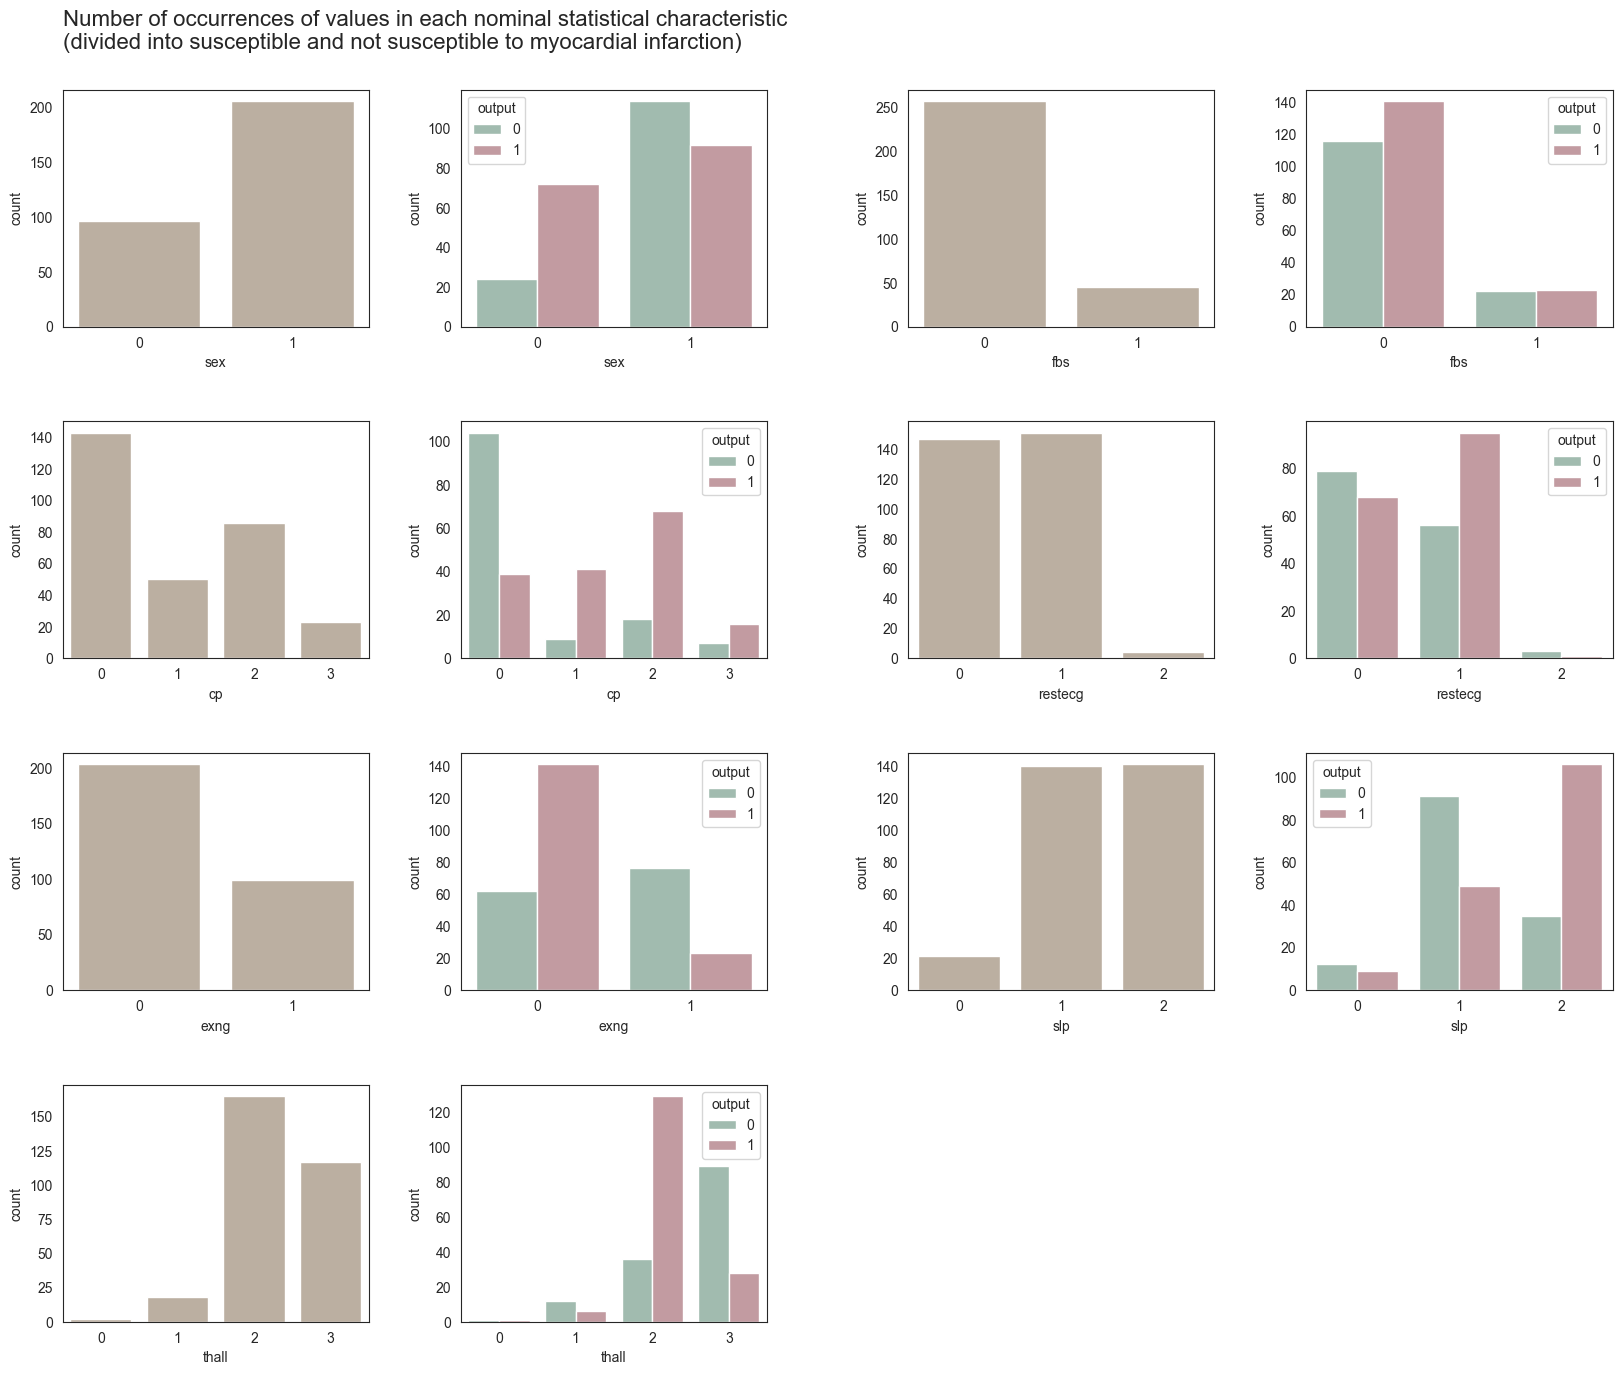

In [3]:
# Declaration of plotting area and title
fig = plt.figure(figsize = (20, 16))
plt.suptitle('Number of occurrences of values in each nominal statistical characteristic \n(divided into susceptible and not susceptible to myocardial infarction)', x = 0.125, y = 0.93, ha = 'left', fontsize = 16)

# Left side of the visualization
gs = fig.add_gridspec(nrows = 1, ncols = 2)
gs1 = gs[0].subgridspec(nrows = 4, ncols = 2, hspace = 0.4, wspace = 0.3)

# Individual graphs of the left side of the visualization
fig.add_subplot(gs1[0, 0:1])
sns.countplot(data = df, x = 'sex', color = color_1)

fig.add_subplot(gs1[0, 1:2])
sns.countplot(data = df, x = 'sex', hue = 'output', palette = color_2)

fig.add_subplot(gs1[1, 0:1])
sns.countplot(data = df, x = 'cp', color = color_1)

fig.add_subplot(gs1[1, 1:2])
sns.countplot(data = df, x = 'cp', hue = 'output', palette = color_2)

fig.add_subplot(gs1[2, 0:1])
sns.countplot(data = df, x = 'exng', color = color_1)

fig.add_subplot(gs1[2, 1:2])
sns.countplot(data = df, x = 'exng', hue = 'output', palette = color_2)

fig.add_subplot(gs1[3, 0:1])
sns.countplot(data = df, x = 'thall', color = color_1)

fig.add_subplot(gs1[3, 1:2])
sns.countplot(data = df, x = 'thall', hue = 'output', palette = color_2)

# Right side of the visualization
gs2 = gs[1].subgridspec(nrows = 4, ncols = 2, hspace = 0.4, wspace = 0.3)

# Individual charts of the right side of the visualization
fig.add_subplot(gs2[0, 0:1])
sns.countplot(data = df, x = 'fbs', color = color_1)

fig.add_subplot(gs2[0, 1:2])
sns.countplot(data = df, x = 'fbs', hue = 'output', palette = color_2)

fig.add_subplot(gs2[1, 0:1])
sns.countplot(data = df, x = 'restecg', color = color_1)

fig.add_subplot(gs2[1, 1:2])
sns.countplot(data = df, x = 'restecg', hue = 'output', palette = color_2)

fig.add_subplot(gs2[2, 0:1])
sns.countplot(data = df, x = 'slp', color = color_1)

fig.add_subplot(gs2[2, 1:2])
sns.countplot(data = df, x = 'slp', hue = 'output', palette = color_2)

# Display charts
plt.show()

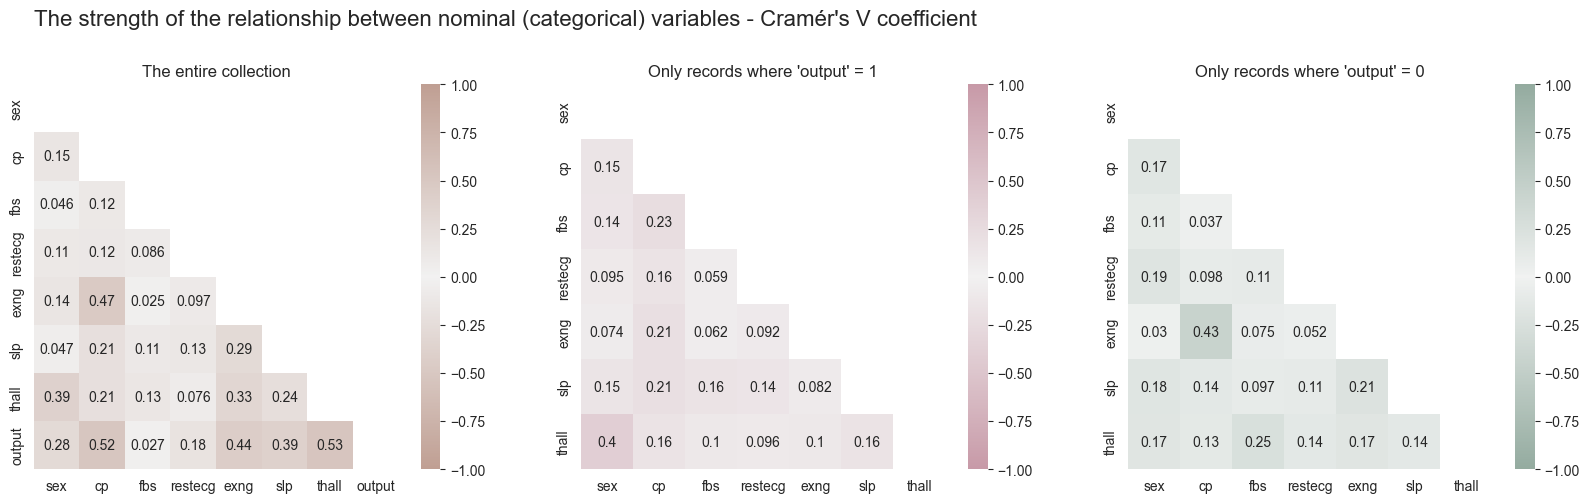

In [4]:
# Declaration of a list of the nominal (categorical) column names
norm_col = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'thall', 'output']

# Determination of Cramér's V coefficient ...
df_norm = df[norm_col]
df_norm_corr = pd.DataFrame(np.zeros((df_norm.shape[1], df_norm.shape[1])), columns = norm_col, index = norm_col)

# ... for the full data set,
for column_1 in df_norm:
    for column_2 in df_norm:
        df_norm_corr.at[column_1, column_2] = association(pd.crosstab(df_norm[column_1], df_norm[column_2]))

# ... for records where 'output' = 0 (not susceptible to heart attack)
df_norm_out0 = df_norm[df_norm.output == 0].drop(['output'], axis = 1)
df_norm_out0_corr = pd.DataFrame(np.zeros((df_norm_out0.shape[1], df_norm_out0.shape[1])), columns = norm_col[:-1], index = norm_col[:-1])

for column_1 in df_norm_out0:
    for column_2 in df_norm_out0:
        df_norm_out0_corr.at[column_1, column_2] = association(pd.crosstab(df_norm_out0[column_1], df_norm_out0[column_2]))

# ... for records where 'output' = 1 (susceptible to heart attack)
df_norm_out1 = df_norm[df_norm.output == 1].drop(['output'], axis = 1)
df_norm_out1_corr = pd.DataFrame(np.zeros((df_norm_out1.shape[1], df_norm_out1.shape[1])), columns = norm_col[:-1], index = norm_col[:-1])

for column_1 in df_norm_out1:
    for column_2 in df_norm_out1:
        df_norm_out1_corr.at[column_1, column_2] = association(pd.crosstab(df_norm_out1[column_1], df_norm_out1[column_2]))


# Declaration of plotting area and title
fig = plt.figure(figsize = (20, 5))
plt.suptitle("The strength of the relationship between nominal (categorical) variables - Cramér's V coefficient", x = 0.125, y = 1.03, ha = 'left', fontsize = 16)

# Individual heat maps
gs = fig.add_gridspec(nrows = 1, ncols = 1)
gs1 = gs[0].subgridspec(nrows = 1, ncols = 3, hspace = 0.4, wspace = 0.2)

fig.add_subplot(gs1[0, 0:1])
sns.heatmap(df_norm_corr, annot = True, cmap = color_3, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_norm_corr))).set(title = 'The entire collection')

fig.add_subplot(gs1[0, 1:2])
sns.heatmap(df_norm_out1_corr, annot = True, cmap = color_5, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_norm_out1_corr))).set(title = "Only records where 'output' = 1")

fig.add_subplot(gs1[0, 2:3])
sns.heatmap(df_norm_out0_corr, annot = True, cmap = color_4, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_norm_out0_corr))).set(title = "Only records where 'output' = 0")

# Display charts
plt.show()

---
### **Empirical distribution of quantitative statistical characteristics**

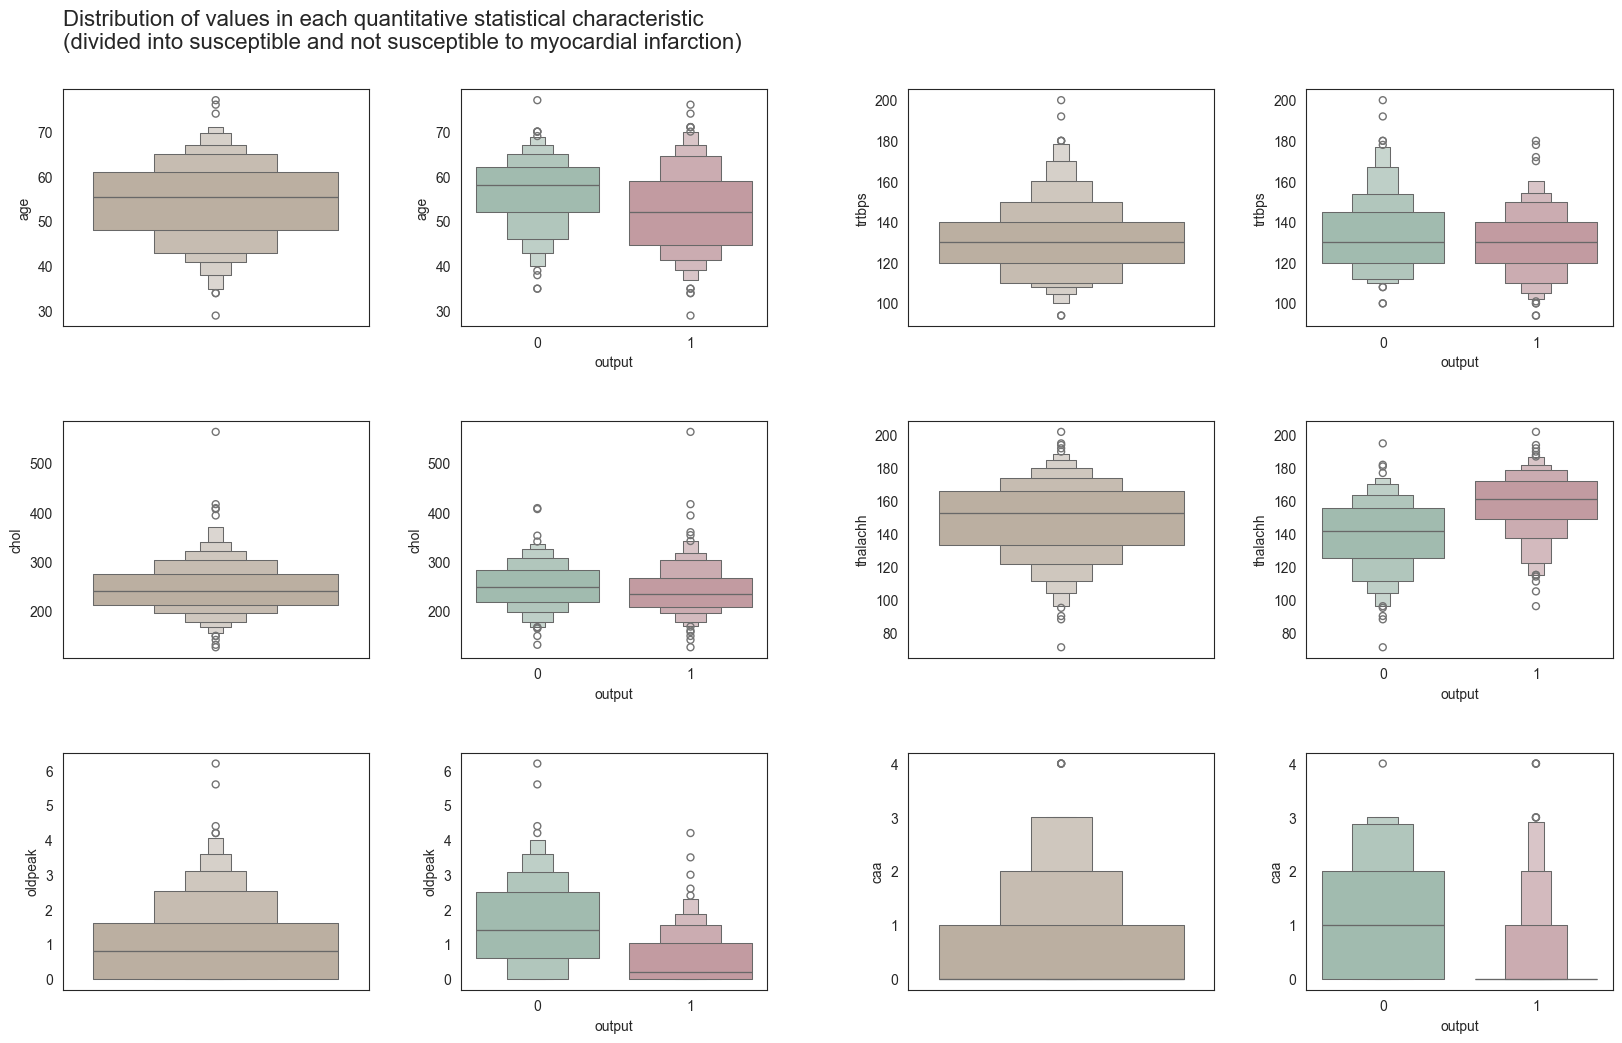

In [5]:
# Declaration of plotting area and title
fig = plt.figure(figsize = (20, 16))
plt.suptitle('Distribution of values in each quantitative statistical characteristic \n(divided into susceptible and not susceptible to myocardial infarction)', x = 0.125, y = 0.93, ha = 'left', fontsize = 16)

# Left side of the visualization
gs = fig.add_gridspec(nrows = 1, ncols = 2)
gs1 = gs[0].subgridspec(nrows = 4, ncols = 2, hspace = 0.4, wspace = 0.3)

# Individual graphs of the left side of the visualization
fig.add_subplot(gs1[0, 0:1])
sns.boxenplot(data = df, y = 'age', color = color_1)

fig.add_subplot(gs1[0, 1:2])
sns.boxenplot(data = df, y = 'age', x = 'output', hue = 'output', palette = color_2, legend = False)

fig.add_subplot(gs1[1, 0:1])
sns.boxenplot(data = df, y = 'chol', color = color_1)

fig.add_subplot(gs1[1, 1:2])
sns.boxenplot(data = df, y = 'chol', x = 'output', hue = 'output', palette = color_2, legend = False)

fig.add_subplot(gs1[2, 0:1])
sns.boxenplot(data = df, y = 'oldpeak', color = color_1)

fig.add_subplot(gs1[2, 1:2])
sns.boxenplot(data = df, y = 'oldpeak', x = 'output', hue = 'output', palette = color_2, legend = False)

# Right side of the visualization
gs2 = gs[1].subgridspec(nrows = 4, ncols = 2, hspace = 0.4, wspace = 0.3)

# Individual charts of the right side of the visualization
fig.add_subplot(gs2[0, 0:1])
sns.boxenplot(data = df, y = 'trtbps', color = color_1)

fig.add_subplot(gs2[0, 1:2])
sns.boxenplot(data = df, y = 'trtbps', x = 'output', hue = 'output', palette = color_2, legend = False)

fig.add_subplot(gs2[1, 0:1])
sns.boxenplot(data = df, y = 'thalachh', color = color_1)

fig.add_subplot(gs2[1, 1:2])
sns.boxenplot(data = df, y = 'thalachh', x = 'output', hue = 'output', palette = color_2, legend = False)

fig.add_subplot(gs2[2, 0:1])
sns.boxenplot(data = df, y = 'caa', color = color_1)

fig.add_subplot(gs2[2, 1:2])
sns.boxenplot(data = df, y = 'caa', x = 'output', hue = 'output', palette = color_2, legend = False)

# Display charts
plt.show()

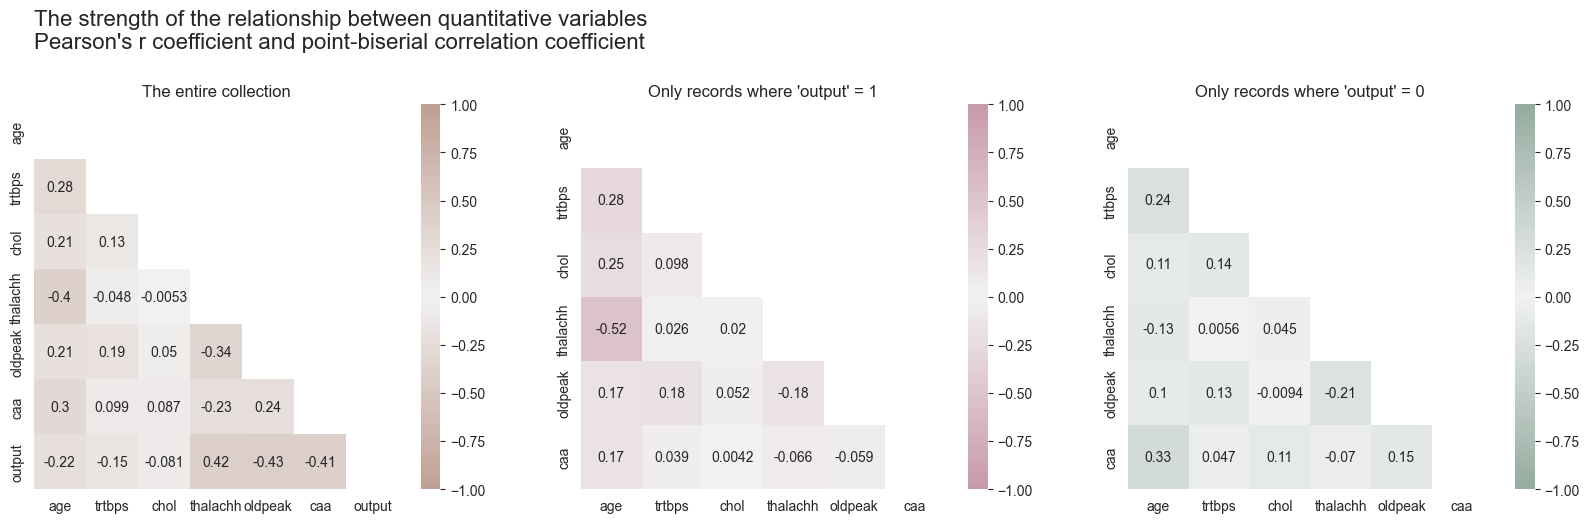

In [6]:
# Declaration of columns with quantitative variables (+ 'output' field)
val_col = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'caa', 'output']

# Determination of Pearson's r coefficient and point-biserial correlation coefficient ...
df_val = df[val_col]

# ... for the full data set,
df_val_corr = df_val.corr()

# ... for records where 'output' = 0 (not susceptible to heart attack)
df_val_out0 = df_val[df_val.output == 0]
df_val_out0_corr = df_val_out0.drop(['output'], axis = 1).corr()

# ... for records where 'output' = 1 (susceptible to heart attack)
df_val_out1 = df_val[df_val.output == 1]
df_val_out1_corr = df_val_out1.drop(['output'], axis = 1).corr()


# Declaration of plotting area and title
fig = plt.figure(figsize = (20, 5))
plt.suptitle("The strength of the relationship between quantitative variables \nPearson's r coefficient and point-biserial correlation coefficient", x = 0.125, y = 1.07, ha = 'left', fontsize = 16)

# Individual heat maps
gs = fig.add_gridspec(nrows = 1, ncols = 1)
gs1 = gs[0].subgridspec(nrows = 1, ncols = 3, hspace = 0.4, wspace = 0.2)

fig.add_subplot(gs1[0, 0:1])
sns.heatmap(df_val_corr, annot = True, cmap = color_3, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_val_corr))).set(title = 'The entire collection')

fig.add_subplot(gs1[0, 1:2])
sns.heatmap(df_val_out1_corr, annot = True, cmap = color_5, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_val_out1_corr))).set(title = "Only records where 'output' = 1")

fig.add_subplot(gs1[0, 2:3])
sns.heatmap(df_val_out0_corr, annot = True, cmap = color_4, vmin = -1, vmax = 1,
            mask = np.triu(np.ones_like(df_val_out0_corr))).set(title = "Only records where 'output' = 0")

# Display charts
plt.show()